# 02 — Exploración: Procesos de Contratación (SECOP II)

**Fuente**: `procesosDeContratacion` — Dataset ID: `p6dx-8zbt`  
**Granularidad**: 1 fila = 1 proceso de compra pública  
**Rol en el proyecto**: Features **pre-contrato** (información disponible antes de que se firme el contrato)

---

## ¿Qué es un proceso de contratación?

Es la fase **anterior** a la firma del contrato. Aquí la entidad pública:
1. Publica la necesidad de compra
2. Los proveedores presentan ofertas
3. Se evalúan y se selecciona un ganador (adjudicación)
4. Se firma el contrato → pasa a `contratosElectronicos`

**¿Por qué es importante para nuestro modelo?**  
Contiene información que ya existe ANTES de que el contrato empiece, como:
- Cuántos proveedores participaron
- El precio base estimado
- La modalidad de selección
- El tipo y subtipo de contrato

Estas variables son **features legítimas** (no causan leakage) porque existen antes del evento que queremos predecir.

---

### Estructura del notebook

1. Configuración y carga de definiciones
2. Descarga de datos filtrados por Obra
3. Exploración general (dimensiones, tipos, nulos)
4. Análisis de variables categóricas
5. Análisis de variables numéricas
6. Análisis de variables temporales
7. Análisis de competencia (proveedores participantes)
8. Llaves de integración con contratosElectronicos
9. Problemas de calidad detectados
10. Conclusiones y variables útiles para modelado

## 1. Configuración inicial

Cargamos las librerías necesarias y las definiciones del dataset desde `dataset.json`.  
También configuramos el cliente Socrata para conectarnos a la API de datos.gov.co.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sodapy import Socrata
from pathlib import Path

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# Cargar definiciones
with open("../dataset.json", encoding="utf-8") as f:
    config = json.load(f)

fuente = config["fuentes"]["procesosDeContratacion"]
APP_TOKEN = config["app_token"]
DATASET_ID = "p6dx-8zbt"

print(f"App token: {APP_TOKEN[:8]}...")
print(f"Dataset ID: {DATASET_ID}")
print(f"Columnas definidas: {len(fuente['columnas'])}")
print(f"\nDefinición: {fuente['definicion'][:200]}...")

App token: nrnMDVHr...
Dataset ID: p6dx-8zbt
Columnas definidas: 59

Definición: El conjunto de datos contiene información detallada sobre las entidades públicas y proveedores registrados en la plataforma SECOP II, utilizada para la gestión de procesos de contratación estatal en C...


## 2. Descarga de datos — Solo contratos de Obra

Descargamos **todos los registros** donde `tipo_de_contrato = 'Obra'` usando la API Socrata (SODA v2).  

**¿Por qué filtramos por tipo y no por modalidad?**  
Como vimos en el notebook 01, solo el 17.8% de los contratos de Obra vienen de la modalidad "Licitación pública Obra Publica". El resto entra por otras modalidades (contratación directa, mínima cuantía, etc.). Si filtráramos por modalidad, perderíamos el 82.2% de los datos.

**Nota técnica**: La descarga se hace en lotes de 10,000 registros porque la API tiene un límite por consulta. El bucle sigue pidiendo hasta que ya no hay más registros.

In [2]:
# Conexión a la API Socrata
client = Socrata("www.datos.gov.co", APP_TOKEN)
client.timeout = 120  # 2 minutos de timeout por petición

# Descarga en lotes de 10,000
all_records = []
batch_size = 10_000
offset = 0

print("Descargando procesos de contratación tipo Obra...")
while True:
    batch = client.get(
        DATASET_ID,
        where="tipo_de_contrato = 'Obra'",
        limit=batch_size,
        offset=offset
    )
    if not batch:
        break
    all_records.extend(batch)
    offset += batch_size
    print(f"  Lote descargado: {len(all_records):,} registros acumulados")

df = pd.DataFrame.from_records(all_records)
print(f"\n{'='*60}")
print(f"Total descargado: {len(df):,} procesos de Obra")
print(f"Columnas recibidas: {len(df.columns)}")

Descargando procesos de contratación tipo Obra...


  Lote descargado: 10,000 registros acumulados


  Lote descargado: 20,000 registros acumulados


  Lote descargado: 30,000 registros acumulados


  Lote descargado: 40,000 registros acumulados


...

  Lote descargado: 110,000 registros acumulados


  Lote descargado: 120,000 registros acumulados


  Lote descargado: 130,000 registros acumulados


  Lote descargado: 138,112 registros acumulados



Total descargado: 138,112 procesos de Obra
Columnas recibidas: 57


### 2.1 Limpieza inicial de columnas tipo dict

Igual que en el notebook 01, la API Socrata a veces devuelve columnas como diccionarios (por ejemplo, URLs vienen como `{"url": "https://..."}`). Convertimos esos diccionarios a texto plano para evitar errores en los análisis.

In [3]:
# Detectar y convertir columnas que contienen diccionarios
dict_cols = []
for col in df.columns:
    if df[col].apply(type).eq(dict).any():
        dict_cols.append(col)
        df[col] = df[col].apply(
            lambda x: x.get("url", str(x)) if isinstance(x, dict) else x
        )

if dict_cols:
    print(f"Columnas convertidas de dict a string: {dict_cols}")
else:
    print("No se encontraron columnas tipo dict.")

Columnas convertidas de dict a string: ['urlproceso']


### 2.2 Guardar datos en formato Parquet

Guardamos los datos descargados en un archivo `.parquet` para no tener que volver a descargarlos cada vez. Parquet es un formato eficiente que mantiene los tipos de datos y ocupa menos espacio que CSV.

In [4]:
# Guardar en parquet
out_path = Path("../data/procesos_contratacion_obra.parquet")
out_path.parent.mkdir(exist_ok=True)
df.to_parquet(out_path, index=False)
print(f"Datos guardados en: {out_path}")
print(f"Tamaño del archivo: {out_path.stat().st_size / 1024 / 1024:.1f} MB")

Datos guardados en: ..\data\procesos_contratacion_obra.parquet
Tamaño del archivo: 33.6 MB


## 3. Exploración general

Veamos las dimensiones del dataset (filas × columnas), los tipos de datos reales, y cuántos valores nulos hay en cada columna.

**¿Qué buscamos?**
- ¿Cuántos procesos de Obra hay?
- ¿Todos los campos numéricos realmente llegaron como números, o como texto?
- ¿Qué columnas tienen muchos valores vacíos?

In [5]:
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n{'='*60}")
print("Tipos de datos (de pandas):")
print(df.dtypes.value_counts())

Dimensiones: 138,112 filas × 57 columnas

Tipos de datos (de pandas):
str    57
Name: count, dtype: int64


### 3.1 Columnas esperadas vs recibidas

Comparamos las 59 columnas definidas en `dataset.json` con las que realmente devolvió la API.  
Esto ayuda a detectar:
- Columnas que existen en la definición pero no llegaron (posiblemente vacías o eliminadas)
- Columnas que llegaron pero no están en la definición (campos nuevos o no documentados)

In [6]:
# Columnas definidas en dataset.json
cols_definidas = {c["nombreCampoApi"] for c in fuente["columnas"]}
cols_recibidas = set(df.columns)

solo_en_def = cols_definidas - cols_recibidas
solo_en_api = cols_recibidas - cols_definidas

print(f"Columnas en definición: {len(cols_definidas)}")
print(f"Columnas en API:        {len(cols_recibidas)}")
print(f"\nSolo en definición (no llegaron): {len(solo_en_def)}")
if solo_en_def:
    for c in sorted(solo_en_def):
        print(f"  - {c}")

print(f"\nSolo en API (no están definidas): {len(solo_en_api)}")
if solo_en_api:
    for c in sorted(solo_en_api):
        print(f"  - {c}")

Columnas en definición: 59
Columnas en API:        57

Solo en definición (no llegaron): 2
  - fecha_de_publicacion_fase
  - fecha_de_publicacion_fase_1

Solo en API (no están definidas): 0


### 3.2 Análisis de nulidad

Contamos cuántos valores nulos (vacíos) tiene cada columna.

**Importante sobre "No Definido"**: Como vimos en el notebook 01, SECOP II usa el texto "No Definido" en lugar de dejar el campo vacío (NULL real). Entonces calculamos dos cosas:
1. **Nulos reales**: campos que pandas detecta como vacíos
2. **Sentinelas**: campos que dicen "No Definido", "No definido", "No D", etc. — que en la práctica significan lo mismo que vacío

La columna `nulidad_efectiva_%` suma ambos para darnos la nulidad real.

In [7]:
# Sentinelas conocidas
SENTINELAS = {"No Definido", "No definido", "No D", "Sin Descripcion", "Sin descripcion", "No Aplica"}

# Calcular nulidad real + sentinelas
nulidad = pd.DataFrame({
    "columna": df.columns,
    "nulos_reales": df.isnull().sum().values,
    "nulos_%": (df.isnull().sum() / len(df) * 100).values,
    "sentinelas": [df[c].isin(SENTINELAS).sum() if df[c].dtype == "object" else 0 for c in df.columns],
})
nulidad["sentinelas_%"] = (nulidad["sentinelas"] / len(df) * 100).round(1)
nulidad["nulidad_efectiva_%"] = (nulidad["nulos_%"] + nulidad["sentinelas_%"]).round(1)
nulidad = nulidad.sort_values("nulidad_efectiva_%", ascending=False)

print(f"Columnas con más del 50% de nulidad efectiva:")
print("="*80)
high_null = nulidad[nulidad["nulidad_efectiva_%"] > 50]
if len(high_null) > 0:
    print(high_null[["columna", "nulos_%", "sentinelas_%", "nulidad_efectiva_%"]].to_string(index=False))
else:
    print("Ninguna columna supera el 50% de nulidad.")

print(f"\n\nResumen completo de nulidad:")
print("="*80)
print(nulidad[["columna", "nulos_%", "sentinelas_%", "nulidad_efectiva_%"]].to_string(index=False))

Columnas con más del 50% de nulidad efectiva:
                    columna   nulos_%  sentinelas_%  nulidad_efectiva_%
       fecha_de_publicacion 89.803927           0.0                89.8
fecha_de_publicacion_fase_2 82.851599           0.0                82.9
         fecha_adjudicacion 63.092273           0.0                63.1


Resumen completo de nulidad:
                       columna   nulos_%  sentinelas_%  nulidad_efectiva_%
          fecha_de_publicacion 89.803927           0.0                89.8
   fecha_de_publicacion_fase_2 82.851599           0.0                82.9
            fecha_adjudicacion 63.092273           0.0                63.1
    fecha_de_apertura_efectiva 31.108086           0.0                31.1
fecha_de_apertura_de_respuesta 28.940280           0.0                28.9
   fecha_de_publicacion_fase_3 28.457339           0.0                28.5
         fecha_de_recepcion_de 27.563137           0.0                27.6
                          fase  1.2

### 3.3 Muestra de los datos

Veamos las primeras 3 filas del dataset para entender cómo se ven los datos reales.

In [8]:
# Primeras filas transpuestas para ver todos los campos
df.head(3).T

,0,1,2
entidad,ALCALDIA LOCAL DE SUMAPAZ,ALCALDIA DE FLORIDABLANCA,GOBERNACION DEL CAQUETA**
nit_entidad,899999061,890205176,800091594
departamento_entidad,Distrito Capital de Bogotá,Santander,Caquetá
ciudad_entidad,Bogotá,Floridablanca,No Definido
ordenentidad,Territorial,Territorial,Territorial
codigo_pci,Centralizada,Centralizada,Centralizada
id_del_proceso,CO1.REQ.848621,CO1.REQ.9500237,CO1.REQ.2438778
referencia_del_proceso,FDLS-LP-098-2019,FLO-INFRA-SA-MC-007-2025 (Manifestación de int...,DC-IN-SAMC-029-2021
ppi,702096124,704323831,703688838
id_del_portafolio,CO1.BDOS.823726,CO1.BDOS.9282110,CO1.BDOS.2369683


## 4. Análisis de variables categóricas

Las variables categóricas son aquellas que contienen texto o categorías fijas (no números).  
Analizamos las más importantes para entender la distribución de los procesos de Obra.

### 4.1 Fase del proceso

Cada proceso pasa por fases: Borrador → Selección → Adjudicación → etc.  

**¿Por qué importa?** Si queremos vincular procesos con contratos firmados, necesitamos que estén en fases avanzadas (Adjudicación o posterior). Procesos en fase Borrador aún no han seleccionado proveedor.

Distribución de fases del proceso:
  Presentación de oferta                     71,464 ( 51.7%)
  Fase de Selección (Presentación de ofertas)   22,688 ( 16.4%)
  Presentación de observaciones              21,874 ( 15.8%)
  Manifestación de interés (Menor Cuantía)   13,415 (  9.7%)
  Fase de ofertas                             4,546 (  3.3%)
  Clarification submission                    1,006 (  0.7%)
  Selección de ofertas (borrador)               740 (  0.5%)
  Pré-Calificación de competidores              639 (  0.5%)
  Presentación de Observaciones                  29 (  0.0%)
  Proceso de ofertas                             12 (  0.0%)


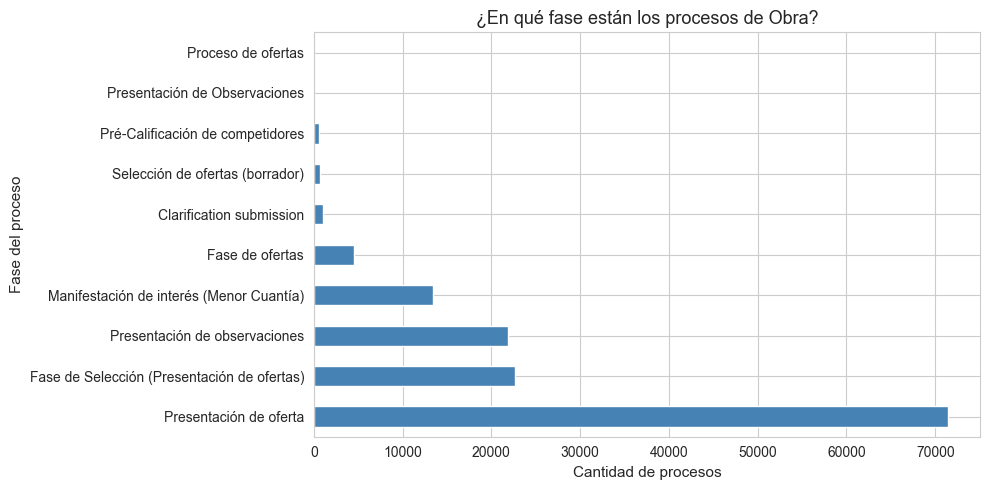


💡 Interpretación:
  - Cada barra muestra cuántos procesos están en cada fase.
  - Eje X (horizontal) = cantidad de procesos.
  - Eje Y (vertical) = nombre de la fase.
  - Los procesos en fases avanzadas son los que ya tienen adjudicación
    y potencialmente un contrato firmado en contratosElectronicos.


In [9]:
# Distribución de fases
if "fase" in df.columns:
    fase_counts = df["fase"].value_counts()
    print("Distribución de fases del proceso:")
    print("="*50)
    for fase, count in fase_counts.items():
        pct = count / len(df) * 100
        print(f"  {fase:40s} {count:>8,} ({pct:5.1f}%)")
    
    # Gráfico
    fig, ax = plt.subplots(figsize=(10, 5))
    fase_counts.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("Cantidad de procesos", fontsize=11)
    ax.set_ylabel("Fase del proceso", fontsize=11)
    ax.set_title("¿En qué fase están los procesos de Obra?", fontsize=13)
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretación:")
    print("  - Cada barra muestra cuántos procesos están en cada fase.")
    print("  - Eje X (horizontal) = cantidad de procesos.")
    print("  - Eje Y (vertical) = nombre de la fase.")
    print("  - Los procesos en fases avanzadas son los que ya tienen adjudicación")
    print("    y potencialmente un contrato firmado en contratosElectronicos.")
else:
    print("Columna 'fase' no encontrada.")

### 4.2 Estado del procedimiento

El estado indica si el proceso está activo, cerrado, desierto (sin adjudicatario), etc.

**¿Por qué importa?** Solo nos interesan procesos que terminaron en adjudicación (es decir, que efectivamente generaron un contrato). Los procesos "Desiertos" o "Cancelados" no tienen contrato.

Estado del procedimiento:
  Seleccionado                               68,237 ( 49.4%)
  Evaluación                                 38,021 ( 27.5%)
  Publicado                                  23,788 ( 17.2%)
  Cancelado                                   6,153 (  4.5%)
  Abierto                                     1,038 (  0.8%)
  Borrador                                      712 (  0.5%)
  Aprobado                                      115 (  0.1%)
  En aprobación                                  33 (  0.0%)
  Suspendido                                     15 (  0.0%)


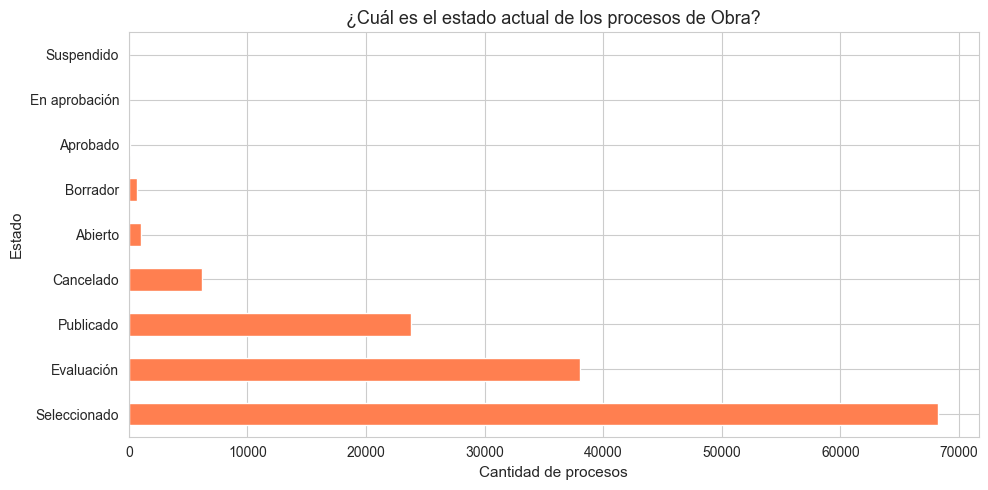


💡 Interpretación:
  - Eje X = cantidad de procesos en cada estado.
  - Eje Y = nombre del estado.
  - 'Adjudicado' o 'Celebrado' = el proceso generó un contrato.
  - 'Desierto' = nadie ganó la licitación (no genera contrato).


In [10]:
# Distribución de estados
if "estado_del_procedimiento" in df.columns:
    estado_counts = df["estado_del_procedimiento"].value_counts()
    print("Estado del procedimiento:")
    print("="*50)
    for estado, count in estado_counts.items():
        pct = count / len(df) * 100
        print(f"  {estado:40s} {count:>8,} ({pct:5.1f}%)")
    
    fig, ax = plt.subplots(figsize=(10, 5))
    estado_counts.plot(kind="barh", ax=ax, color="coral")
    ax.set_xlabel("Cantidad de procesos", fontsize=11)
    ax.set_ylabel("Estado", fontsize=11)
    ax.set_title("¿Cuál es el estado actual de los procesos de Obra?", fontsize=13)
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretación:")
    print("  - Eje X = cantidad de procesos en cada estado.")
    print("  - Eje Y = nombre del estado.")
    print("  - 'Adjudicado' o 'Celebrado' = el proceso generó un contrato.")
    print("  - 'Desierto' = nadie ganó la licitación (no genera contrato).")
else:
    print("Columna 'estado_del_procedimiento' no encontrada.")

### 4.3 Campo "Adjudicado"

Este campo indica directamente si el proceso fue adjudicado (Sí/No).  
Solo los procesos adjudicados deberían tener un contrato en `contratosElectronicos`.

In [11]:
if "adjudicado" in df.columns:
    adj_counts = df["adjudicado"].value_counts()
    print("¿Fue adjudicado el proceso?")
    print("="*40)
    for val, count in adj_counts.items():
        pct = count / len(df) * 100
        print(f"  {str(val):20s} {count:>8,} ({pct:5.1f}%)")
else:
    print("Columna 'adjudicado' no encontrada.")

¿Fue adjudicado el proceso?
  No                     82,204 ( 59.5%)
  Si                     55,908 ( 40.5%)


### 4.4 Modalidad de contratación

La modalidad indica CÓMO se seleccionó al proveedor. Recordemos que es un eje independiente del tipo de contrato.

**Ejemplo**: Un contrato de Obra puede llegar por:
- Licitación pública (procesos grandes, competitivos)
- Contratación directa (sin competencia, por excepción legal)
- Mínima cuantía (montos pequeños, proceso simplificado)

Modalidad de contratación (top 15):
  Selección Abreviada de Menor Cuantía                 46,720 ( 33.8%)
  Licitación pública Obra Publica                      32,270 ( 23.4%)
  Contratación régimen especial                        27,947 ( 20.2%)
  Mínima cuantía                                       13,358 (  9.7%)
  Contratación directa                                 10,085 (  7.3%)
  Contratación régimen especial (con ofertas)           3,316 (  2.4%)
  Contratación Directa (con ofertas)                    1,904 (  1.4%)
  Licitación pública                                    1,735 (  1.3%)
  Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes      777 (  0.6%)


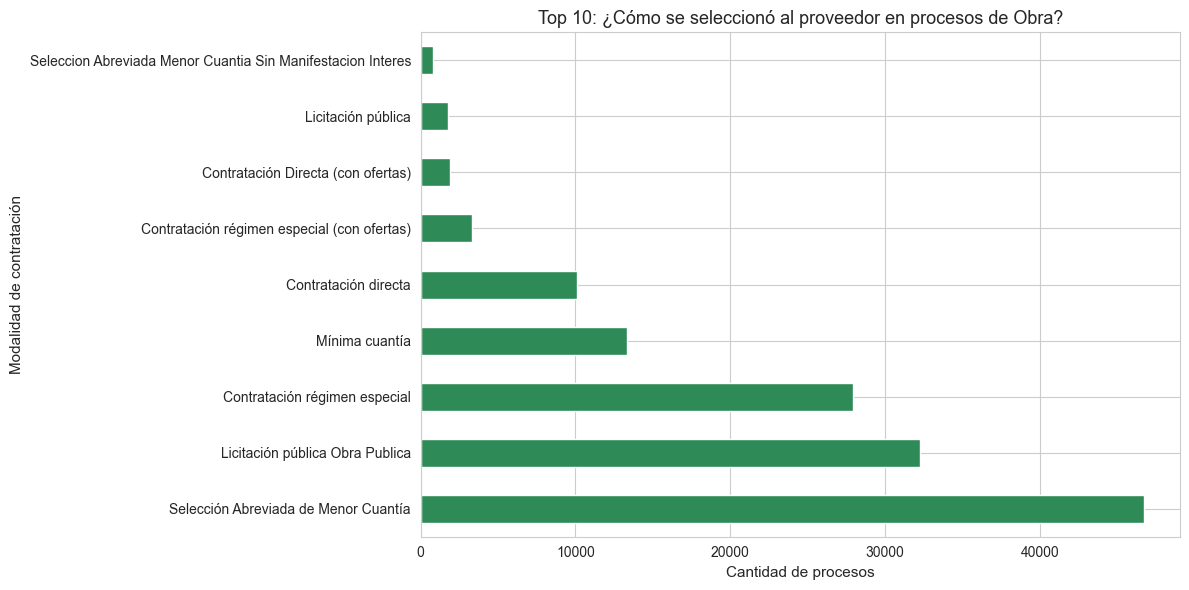


💡 Interpretación:
  - Cada barra = una modalidad de selección del proveedor.
  - Eje X = cuántos procesos usaron esa modalidad.
  - 'Licitación pública' = proceso competitivo abierto (montos grandes).
  - 'Mínima cuantía' = proceso simplificado (montos pequeños).
  - 'Contratación directa' = sin competencia (excepciones legales).


In [12]:
if "modalidad_de_contratacion" in df.columns:
    mod_counts = df["modalidad_de_contratacion"].value_counts()
    print("Modalidad de contratación (top 15):")
    print("="*60)
    for mod, count in mod_counts.head(15).items():
        pct = count / len(df) * 100
        print(f"  {mod:50s} {count:>8,} ({pct:5.1f}%)")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    mod_counts.head(10).plot(kind="barh", ax=ax, color="seagreen")
    ax.set_xlabel("Cantidad de procesos", fontsize=11)
    ax.set_ylabel("Modalidad de contratación", fontsize=11)
    ax.set_title("Top 10: ¿Cómo se seleccionó al proveedor en procesos de Obra?", fontsize=13)
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretación:")
    print("  - Cada barra = una modalidad de selección del proveedor.")
    print("  - Eje X = cuántos procesos usaron esa modalidad.")
    print("  - 'Licitación pública' = proceso competitivo abierto (montos grandes).")
    print("  - 'Mínima cuantía' = proceso simplificado (montos pequeños).")
    print("  - 'Contratación directa' = sin competencia (excepciones legales).")
else:
    print("Columna 'modalidad_de_contratacion' no encontrada.")

### 4.5 Estado resumen

Campo que resume el estado general del proceso. Útil para entender la distribución rápidamente.

In [13]:
if "estado_resumen" in df.columns:
    er_counts = df["estado_resumen"].value_counts()
    print("Estado resumen:")
    print("="*50)
    for val, count in er_counts.items():
        pct = count / len(df) * 100
        print(f"  {str(val):40s} {count:>8,} ({pct:5.1f}%)")
else:
    print("Columna 'estado_resumen' no encontrada.")

Estado resumen:


  Adjudicado                                 58,628 ( 42.4%)
  Presentación de oferta                     33,877 ( 24.5%)
  Presentación de observaciones              21,874 ( 15.8%)
  Manifestación de interés (Menor Cuantía)   13,415 (  9.7%)
  Fase de Selección (Presentación de ofertas)    4,679 (  3.4%)
  No Definido                                 1,699 (  1.2%)
  Fase de ofertas                             1,522 (  1.1%)
  Clarification submission                    1,006 (  0.7%)
  Selección de ofertas (borrador)               740 (  0.5%)
  Pré-Calificación de competidores              639 (  0.5%)
  Presentación de Observaciones                  29 (  0.0%)
  Proceso de ofertas                              4 (  0.0%)


### 4.6 Distribución geográfica (departamento de la entidad)

¿De qué departamentos vienen los procesos de Obra? Esto puede ser un feature geográfico para el modelo.

Top 15 departamentos con más procesos de Obra:


  Distrito Capital de Bogotá            42,022 ( 30.4%)
  Antioquia                             14,302 ( 10.4%)
  Valle del Cauca                        8,156 (  5.9%)
  No Definido                            7,287 (  5.3%)
  Cundinamarca                           6,501 (  4.7%)
  Caldas                                 5,792 (  4.2%)
  Boyacá                                 5,170 (  3.7%)
  Santander                              4,920 (  3.6%)
  Norte de Santander                     3,614 (  2.6%)
  Tolima                                 3,422 (  2.5%)
  Bolívar                                3,177 (  2.3%)
  Huila                                  3,173 (  2.3%)
  Nariño                                 3,116 (  2.3%)
  Cauca                                  2,670 (  1.9%)
  Risaralda                              2,542 (  1.8%)


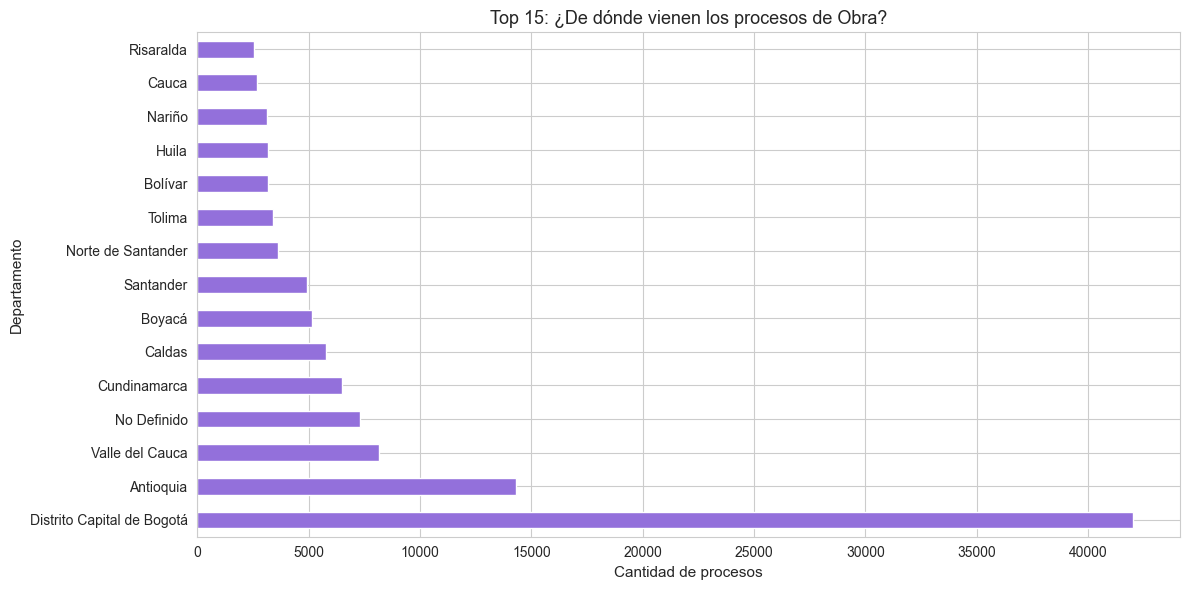


💡 Interpretación:
  - Cada barra = un departamento de Colombia.
  - Eje X = cuántos procesos de Obra se publicaron desde ese departamento.
  - Los departamentos con más procesos suelen ser los de mayor inversión pública.


In [14]:
# Buscar columna de departamento
dept_col = None
for c in ["departamento_entidad", "departamento"]:
    if c in df.columns:
        dept_col = c
        break

if dept_col:
    dept_counts = df[dept_col].value_counts()
    print(f"Top 15 departamentos con más procesos de Obra:")
    print("="*50)
    for dept, count in dept_counts.head(15).items():
        pct = count / len(df) * 100
        print(f"  {dept:35s} {count:>8,} ({pct:5.1f}%)")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    dept_counts.head(15).plot(kind="barh", ax=ax, color="mediumpurple")
    ax.set_xlabel("Cantidad de procesos", fontsize=11)
    ax.set_ylabel("Departamento", fontsize=11)
    ax.set_title("Top 15: ¿De dónde vienen los procesos de Obra?", fontsize=13)
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretación:")
    print("  - Cada barra = un departamento de Colombia.")
    print("  - Eje X = cuántos procesos de Obra se publicaron desde ese departamento.")
    print("  - Los departamentos con más procesos suelen ser los de mayor inversión pública.")
else:
    print("No se encontró columna de departamento.")

### 4.7 Orden de la entidad

Indica si la entidad es de orden Nacional, Territorial (departamental o municipal), etc.  
Puede ser un feature interesante: ¿contratos nacionales vs municipales tienen diferente riesgo?

In [15]:
orden_col = None
for c in ["ordenentidad", "orden"]:
    if c in df.columns:
        orden_col = c
        break

if orden_col:
    print(f"Distribución de orden de la entidad ({orden_col}):")
    print("="*50)
    for val, count in df[orden_col].value_counts().items():
        pct = count / len(df) * 100
        print(f"  {str(val):30s} {count:>8,} ({pct:5.1f}%)")
else:
    print("No se encontró columna de orden.")

Distribución de orden de la entidad (ordenentidad):
  Territorial                      88,255 ( 63.9%)
  Nacional                         47,860 ( 34.7%)
  Corporación Autónoma              1,997 (  1.4%)


## 5. Análisis de variables numéricas

Las variables numéricas incluyen montos, cantidades de proveedores, lotes, etc.  
Pero primero debemos verificar si realmente llegaron como números o como texto (cosa que pasa frecuentemente con la API Socrata).

### 5.1 Conversión de tipos

Intentamos convertir a número las columnas que deberían ser numéricas según la definición.

In [16]:
# Columnas que deberían ser numéricas según la definición
cols_numericas_def = [c["nombreCampoApi"] for c in fuente["columnas"] if c["tipo"] == "Número"]
print(f"Columnas definidas como numéricas: {len(cols_numericas_def)}")

# Verificar cuáles están en el df y su tipo actual
print(f"\n{'Columna':<45} {'Tipo actual':<15} {'Convertida?'}")
print("="*75)
for col in cols_numericas_def:
    if col in df.columns:
        tipo_antes = str(df[col].dtype)
        df[col] = pd.to_numeric(df[col], errors="coerce")
        tipo_despues = str(df[col].dtype)
        cambio = "Sí" if tipo_antes != tipo_despues else "Ya era numérica"
        print(f"  {col:<43} {tipo_antes:<15} {cambio}")
    else:
        print(f"  {col:<43} {'NO EXISTE':<15} -")

Columnas definidas como numéricas: 14

Columna                                       Tipo actual     Convertida?


  precio_base                                 str             Sí
  duracion                                    str             Sí
  proveedores_invitados                       str             Sí


  proveedores_con_invitacion                  str             Sí


  visualizaciones_del                         str             Sí
  proveedores_que_manifestaron                str             Sí
  respuestas_al_procedimiento                 str             Sí
  respuestas_externas                         str             Sí


  conteo_de_respuestas_a_ofertas              str             Sí
  proveedores_unicos_con                      str             Sí


  numero_de_lotes                             str             Sí
  id_estado_del_procedimiento                 str             Sí
  valor_total_adjudicacion                    str             Sí


  codigo_entidad                              str             Sí


### 5.2 Precio base (estimado del proceso)

El precio base es el valor que la entidad estima que costará el proceso ANTES de adjudicar. Es un feature muy valioso porque:
- Existe antes de la firma del contrato (no es leakage)
- Se puede comparar con el valor final del contrato para detectar subestimación/sobreestimación

**¿Qué significan los percentiles en el gráfico?**
- P25 = el 25% de los procesos tiene un precio base menor a este valor
- P50 (mediana) = la mitad de los procesos está por debajo de este valor
- P75 = el 75% está por debajo
- La diferencia entre mediana y media indica si hay valores extremos (contratos muy caros que "jalan" el promedio hacia arriba)

Precio base del proceso (valor estimado antes de adjudicar):
  Registros con dato: 138,112 de 138,112 (100.0%)
  Mínimo:    $      -6,087,355,200
  P25:       $          68,426,759  ← 25% de procesos cuestan menos que esto
  Mediana:   $         299,613,866  ← la mitad cuesta menos que esto
  Media:     $      90,702,203,899  ← promedio (afectado por valores extremos)
  P75:       $       1,522,212,760  ← 75% cuesta menos que esto
  P95:       $      31,057,972,452  ← solo 5% supera este valor
  Máximo:    $11,111,111,111,111,112


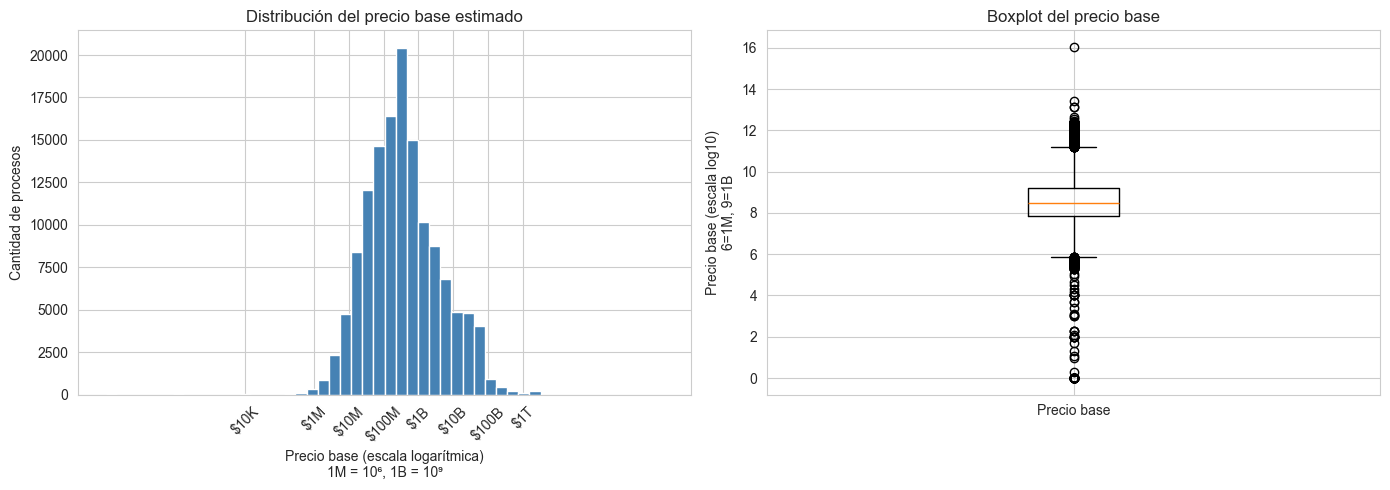


💡 Interpretación de los gráficos:
  IZQUIERDA (Histograma):
    - Eje X = precio base en escala logarítmica (porque los valores van de miles a billones).
    - Eje Y = cuántos procesos tienen ese rango de precio.
    - La 'montaña' muestra dónde se concentra la mayoría de procesos.
    - Ejemplo: si la montaña está en 10⁷ ($10M), la mayoría de obras cuestan ~$10 millones.
  DERECHA (Boxplot):
    - La caja central contiene el 50% de los procesos (del P25 al P75).
    - La línea dentro de la caja = la mediana (P50).
    - Los puntos fuera de los 'bigotes' = valores atípicos (obras inusualmente caras o baratas).


In [17]:
if "precio_base" in df.columns:
    precio = df["precio_base"].dropna()
    print(f"Precio base del proceso (valor estimado antes de adjudicar):")
    print("="*60)
    print(f"  Registros con dato: {len(precio):,} de {len(df):,} ({len(precio)/len(df)*100:.1f}%)")
    print(f"  Mínimo:    ${precio.min():>20,.0f}")
    print(f"  P25:       ${precio.quantile(0.25):>20,.0f}  ← 25% de procesos cuestan menos que esto")
    print(f"  Mediana:   ${precio.median():>20,.0f}  ← la mitad cuesta menos que esto")
    print(f"  Media:     ${precio.mean():>20,.0f}  ← promedio (afectado por valores extremos)")
    print(f"  P75:       ${precio.quantile(0.75):>20,.0f}  ← 75% cuesta menos que esto")
    print(f"  P95:       ${precio.quantile(0.95):>20,.0f}  ← solo 5% supera este valor")
    print(f"  Máximo:    ${precio.max():>20,.0f}")
    
    # Gráfico: distribución del precio base (escala log)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma con escala logarítmica
    precio_positivo = precio[precio > 0]
    axes[0].hist(np.log10(precio_positivo), bins=50, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Precio base (escala logarítmica)\n1M = 10⁶, 1B = 10⁹", fontsize=10)
    axes[0].set_ylabel("Cantidad de procesos", fontsize=10)
    axes[0].set_title("Distribución del precio base estimado", fontsize=12)
    # Agregar etiquetas legibles
    ticks = [4, 6, 7, 8, 9, 10, 11, 12]
    labels = ["$10K", "$1M", "$10M", "$100M", "$1B", "$10B", "$100B", "$1T"]
    axes[0].set_xticks(ticks)
    axes[0].set_xticklabels(labels, rotation=45)
    
    # Boxplot
    axes[1].boxplot(np.log10(precio_positivo), vert=True)
    axes[1].set_ylabel("Precio base (escala log10)\n6=1M, 9=1B", fontsize=10)
    axes[1].set_title("Boxplot del precio base", fontsize=12)
    axes[1].set_xticklabels(["Precio base"])
    
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretación de los gráficos:")
    print("  IZQUIERDA (Histograma):")
    print("    - Eje X = precio base en escala logarítmica (porque los valores van de miles a billones).")
    print("    - Eje Y = cuántos procesos tienen ese rango de precio.")
    print("    - La 'montaña' muestra dónde se concentra la mayoría de procesos.")
    print("    - Ejemplo: si la montaña está en 10⁷ ($10M), la mayoría de obras cuestan ~$10 millones.")
    print("  DERECHA (Boxplot):")
    print("    - La caja central contiene el 50% de los procesos (del P25 al P75).")
    print("    - La línea dentro de la caja = la mediana (P50).")
    print("    - Los puntos fuera de los 'bigotes' = valores atípicos (obras inusualmente caras o baratas).")
else:
    print("Columna 'precio_base' no encontrada.")

### 5.3 Duración estimada del proceso

La duración estimada indica cuánto tiempo se proyectó para ejecutar el contrato (antes de firmarlo).  
Hay dos columnas relacionadas:
- `duracion`: el valor numérico (ej: 180)
- `unidad_de_duracion`: la unidad (ej: "Día(s)", "Mes(es)")

**Normalización**: Para comparar, convertimos todo a días.

Duración estimada del proceso:
  Registros con dato: 138,112 de 138,112

Unidades de duración:
  Mes(es)                72,963 ( 52.8%)
  día(s)                 64,447 ( 46.7%)
  Semana(s)                 488 (  0.4%)
  Año(s)                    187 (  0.1%)
  Hora(s)                    27 (  0.0%)



Duración normalizada a días:
  Mínimo:             0 días
  P25:               30 días
  Mediana:           90 días
  Media:            458 días
  P75:              176 días
  Máximo:    27,112,025 días


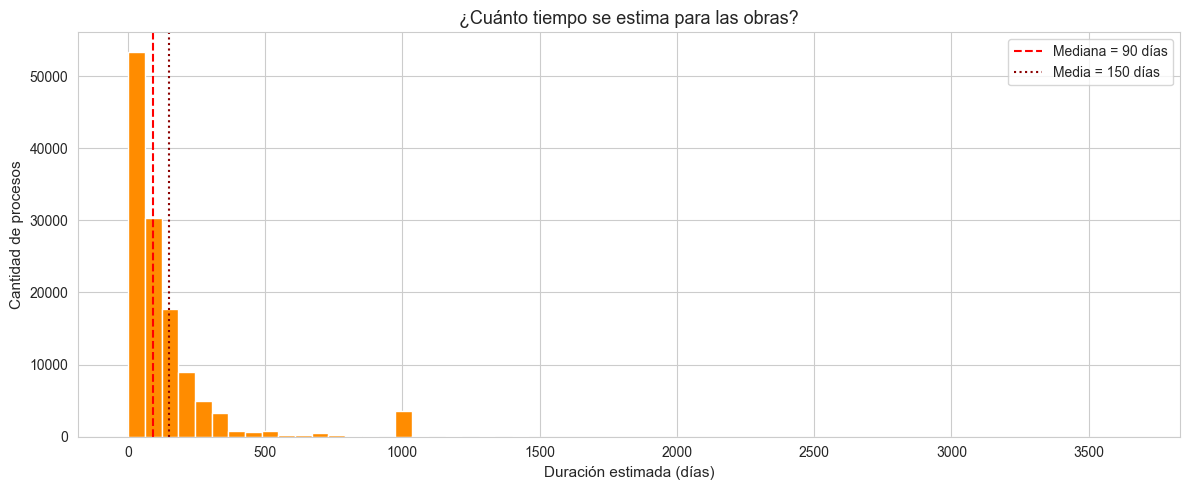


💡 Interpretación:
  - Eje X = duración estimada en días (ej: 180 días = ~6 meses).
  - Eje Y = cuántos procesos tienen esa duración.
  - Línea roja punteada = mediana (la mitad de las obras dura menos que esto).
  - Si la media es mayor que la mediana, hay algunas obras MUY largas
    que jalan el promedio hacia arriba.


In [18]:
if "duracion" in df.columns:
    print("Duración estimada del proceso:")
    print("="*50)
    dur = df["duracion"].dropna()
    print(f"  Registros con dato: {len(dur):,} de {len(df):,}")
    
    if "unidad_de_duracion" in df.columns:
        print(f"\nUnidades de duración:")
        for val, count in df["unidad_de_duracion"].value_counts().items():
            pct = count / len(df) * 100
            print(f"  {str(val):20s} {count:>8,} ({pct:5.1f}%)")
        
        # Normalizar a días
        def to_days(row):
            d = row.get("duracion", np.nan)
            u = str(row.get("unidad_de_duracion", "")).lower()
            if pd.isna(d):
                return np.nan
            if "mes" in u:
                return d * 30
            elif "a" in u and "ño" in u:
                return d * 365
            else:  # días por defecto
                return d
        
        df["duracion_dias"] = df.apply(to_days, axis=1)
        dur_dias = df["duracion_dias"].dropna()
        
        print(f"\nDuración normalizada a días:")
        print(f"  Mínimo:    {dur_dias.min():>10,.0f} días")
        print(f"  P25:       {dur_dias.quantile(0.25):>10,.0f} días")
        print(f"  Mediana:   {dur_dias.median():>10,.0f} días")
        print(f"  Media:     {dur_dias.mean():>10,.0f} días")
        print(f"  P75:       {dur_dias.quantile(0.75):>10,.0f} días")
        print(f"  Máximo:    {dur_dias.max():>10,.0f} días")
        
        # Gráfico
        fig, ax = plt.subplots(figsize=(12, 5))
        dur_valida = dur_dias[(dur_dias > 0) & (dur_dias <= 3650)]  # hasta 10 años
        ax.hist(dur_valida, bins=60, color="darkorange", edgecolor="white")
        ax.axvline(dur_valida.median(), color="red", linestyle="--", label=f"Mediana = {dur_valida.median():.0f} días")
        ax.axvline(dur_valida.mean(), color="darkred", linestyle=":", label=f"Media = {dur_valida.mean():.0f} días")
        ax.set_xlabel("Duración estimada (días)", fontsize=11)
        ax.set_ylabel("Cantidad de procesos", fontsize=11)
        ax.set_title("¿Cuánto tiempo se estima para las obras?", fontsize=13)
        ax.legend(fontsize=10)
        plt.tight_layout()
        plt.show()
        
        print("\n💡 Interpretación:")
        print("  - Eje X = duración estimada en días (ej: 180 días = ~6 meses).")
        print("  - Eje Y = cuántos procesos tienen esa duración.")
        print("  - Línea roja punteada = mediana (la mitad de las obras dura menos que esto).")
        print("  - Si la media es mayor que la mediana, hay algunas obras MUY largas")
        print("    que jalan el promedio hacia arriba.")
else:
    print("Columna 'duracion' no encontrada.")

### 5.4 Valor total de adjudicación

Es el valor final por el cual se adjudicó el proceso. Comparar con el `precio_base` puede revelar subestimación/sobreestimación.

In [19]:
if "valor_total_adjudicacion" in df.columns:
    val_adj = df["valor_total_adjudicacion"].dropna()
    print(f"Valor total de adjudicación:")
    print("="*60)
    print(f"  Registros con dato: {len(val_adj):,} de {len(df):,} ({len(val_adj)/len(df)*100:.1f}%)")
    if len(val_adj) > 0:
        print(f"  Mínimo:    ${val_adj.min():>20,.0f}")
        print(f"  Mediana:   ${val_adj.median():>20,.0f}")
        print(f"  Media:     ${val_adj.mean():>20,.0f}")
        print(f"  Máximo:    ${val_adj.max():>20,.0f}")
        print(f"  Ceros:     {(val_adj == 0).sum():>8,} ({(val_adj == 0).sum()/len(val_adj)*100:.1f}%)")
else:
    print("Columna 'valor_total_adjudicacion' no encontrada.")

Valor total de adjudicación:
  Registros con dato: 138,112 de 138,112 (100.0%)
  Mínimo:    $                   0
  Mediana:   $                   0
  Media:     $ 109,098,463,644,441
  Máximo:    $6,004,813,150,601,998,336
  Ceros:       82,297 (59.6%)


## 6. Análisis de competencia — Proveedores participantes

Esta es una de las secciones más valiosas para el modelo predictivo. Las columnas de competencia nos dicen cuánto interés generó cada proceso.

**Hipótesis**: Procesos con poca competencia (pocos proveedores) podrían tener mayor riesgo de problemas.

Variables de competencia:
- `proveedores_invitados`: cuántos proveedores fueron invitados a participar
- `proveedores_con_invitacion`: cuántos recibieron invitación directa
- `proveedores_que_manifestaron`: cuántos mostraron interés
- `proveedores_unicos_con`: cuántos enviaron respuestas únicas
- `respuestas_al_procedimiento`: total de respuestas recibidas
- `visualizaciones_del`: cuántas veces se consultó el proceso en la plataforma

In [20]:
# Variables de competencia
competition_cols = [
    "proveedores_invitados",
    "proveedores_con_invitacion",
    "proveedores_que_manifestaron",
    "proveedores_unicos_con",
    "respuestas_al_procedimiento",
    "respuestas_externas",
    "conteo_de_respuestas_a_ofertas",
    "visualizaciones_del"
]

comp_available = [c for c in competition_cols if c in df.columns]

print("Variables de competencia disponibles:")
print("="*80)
print(f"{'Variable':<42} {'N datos':>8} {'Media':>10} {'Mediana':>10} {'Max':>10}")
print("-"*80)
for col in comp_available:
    data = df[col].dropna()
    if len(data) > 0:
        print(f"  {col:<40} {len(data):>8,} {data.mean():>10.1f} {data.median():>10.0f} {data.max():>10,.0f}")
    else:
        print(f"  {col:<40} {'SIN DATOS':>8}")

Variables de competencia disponibles:
Variable                                    N datos      Media    Mediana        Max
--------------------------------------------------------------------------------
  proveedores_invitados                     138,112       10.2          0      7,288
  proveedores_con_invitacion                138,112        4.5          0        389
  proveedores_que_manifestaron              138,112        0.0          0          0
  proveedores_unicos_con                    138,112        7.9          0        254
  respuestas_al_procedimiento               138,112        8.0          0        254
  respuestas_externas                       138,112        0.0          0         17
  conteo_de_respuestas_a_ofertas            138,112        0.0          0          0
  visualizaciones_del                       138,112       85.0         51        953


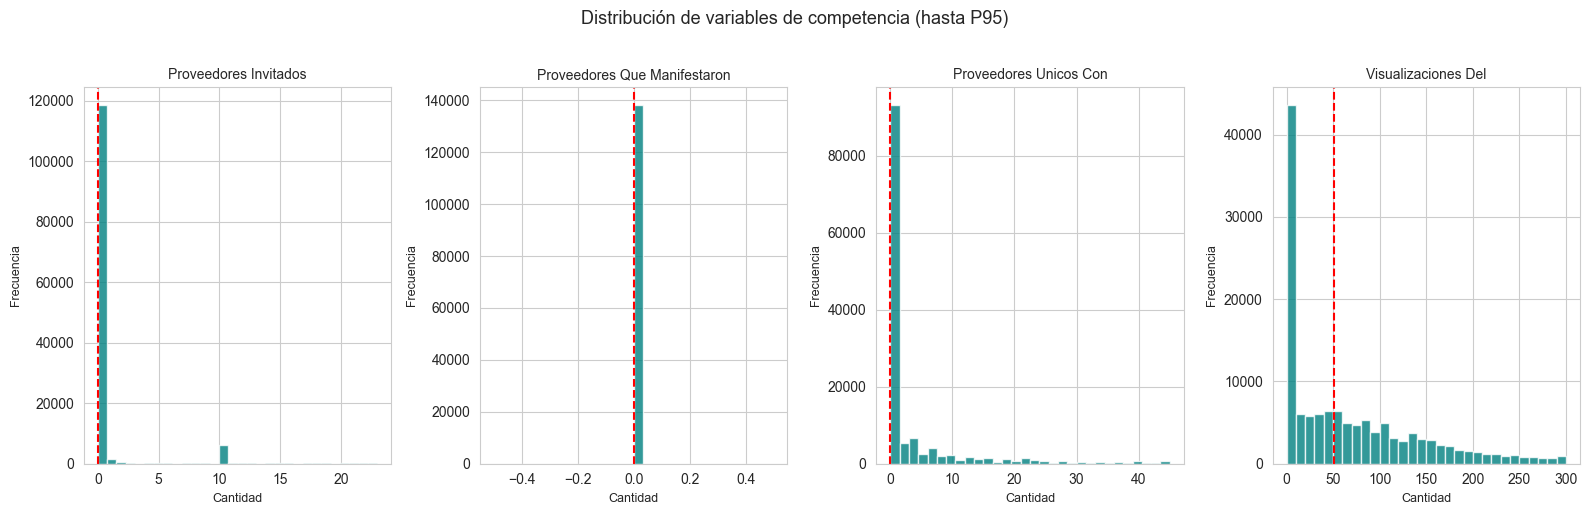

💡 Interpretación:
  - Cada gráfico muestra una variable de competencia.
  - Eje X = valor de la variable (ej: número de proveedores).
  - Eje Y = cuántos procesos tienen ese valor.
  - Línea roja = mediana.
  - Se muestran solo hasta el percentil 95 (P95) para que los valores
    extremos no distorsionen la visualización.
  - Si la mayoría de barras están pegadas a 0, significa que muchos
    procesos tienen poca competencia.


In [21]:
# Gráfico de las principales variables de competencia
key_comp = [c for c in ["proveedores_invitados", "proveedores_que_manifestaron", 
                         "proveedores_unicos_con", "visualizaciones_del"] if c in df.columns]

if key_comp:
    fig, axes = plt.subplots(1, len(key_comp), figsize=(4*len(key_comp), 5))
    if len(key_comp) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, key_comp):
        data = df[col].dropna()
        # Limitar al percentil 95 para visualización
        p95 = data.quantile(0.95)
        data_viz = data[data <= p95]
        ax.hist(data_viz, bins=30, color="teal", edgecolor="white", alpha=0.8)
        ax.axvline(data.median(), color="red", linestyle="--", linewidth=1.5)
        ax.set_title(col.replace("_", " ").title()[:30], fontsize=10)
        ax.set_xlabel("Cantidad", fontsize=9)
        ax.set_ylabel("Frecuencia", fontsize=9)
    
    plt.suptitle("Distribución de variables de competencia (hasta P95)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    
    print("💡 Interpretación:")
    print("  - Cada gráfico muestra una variable de competencia.")
    print("  - Eje X = valor de la variable (ej: número de proveedores).")
    print("  - Eje Y = cuántos procesos tienen ese valor.")
    print("  - Línea roja = mediana.")
    print("  - Se muestran solo hasta el percentil 95 (P95) para que los valores")
    print("    extremos no distorsionen la visualización.")
    print("  - Si la mayoría de barras están pegadas a 0, significa que muchos")
    print("    procesos tienen poca competencia.")

## 7. Análisis de variables temporales

Las fechas nos permiten entender la línea de tiempo de cada proceso.  
Los campos temporales disponibles son:
- `fecha_de_publicacion_del`: cuándo se publicó el proceso
- Varias fechas de fases (borrador, selección, precalificación)
- `fecha_de_recepcion_de`: hasta cuándo se reciben ofertas
- `fecha_adjudicacion`: cuándo se adjudicó

**Feature potencial**: el tiempo entre publicación y adjudicación (duración del proceso de selección).

In [22]:
# Columnas temporales definidas
cols_temporales_def = [c["nombreCampoApi"] for c in fuente["columnas"] 
                       if c["tipo"] == "Marca de tiempo variable"]

print(f"Columnas temporales definidas ({len(cols_temporales_def)}):")
print("="*70)
for col in cols_temporales_def:
    if col in df.columns:
        # Convertir a datetime
        df[col] = pd.to_datetime(df[col], errors="coerce")
        n_valid = df[col].notna().sum()
        pct = n_valid / len(df) * 100
        if n_valid > 0:
            min_date = df[col].min().strftime("%Y-%m-%d")
            max_date = df[col].max().strftime("%Y-%m-%d")
            print(f"  {col:<40} {n_valid:>8,} ({pct:5.1f}%)  [{min_date} → {max_date}]")
        else:
            print(f"  {col:<40} {n_valid:>8,} ({pct:5.1f}%)  [SIN DATOS]")
    else:
        print(f"  {col:<40} NO EXISTE en los datos")

Columnas temporales definidas (11):
  fecha_de_publicacion_del                  136,575 ( 98.9%)  [2015-05-20 → 2026-03-01]
  fecha_de_ultima_publicaci                 136,575 ( 98.9%)  [2015-05-20 → 2026-03-01]
  fecha_de_publicacion_fase                NO EXISTE en los datos
  fecha_de_publicacion_fase_1              NO EXISTE en los datos
  fecha_de_publicacion                       14,082 ( 10.2%)  [2016-04-14 → 2026-02-27]
  fecha_de_publicacion_fase_2                23,684 ( 17.1%)  [2016-03-17 → 2026-02-28]
  fecha_de_publicacion_fase_3                98,809 ( 71.5%)  [2015-05-20 → 2026-03-01]
  fecha_de_recepcion_de                     100,044 ( 72.4%)  [2015-06-09 → 2026-06-30]


  fecha_de_apertura_de_respuesta             98,142 ( 71.1%)  [2015-06-09 → 2026-08-02]
  fecha_de_apertura_efectiva                 95,148 ( 68.9%)  [2015-10-21 → 2026-08-02]
  fecha_adjudicacion                         50,974 ( 36.9%)  [2015-11-04 → 2026-02-28]


Procesos de Obra publicados por año:
    2015         49 (  0.0%)
    2016        225 (  0.2%)
    2017      1,302 (  0.9%)
    2018      5,049 (  3.7%)
    2019     13,966 ( 10.1%)
    2020      6,896 (  5.0%)
    2021     12,974 (  9.4%)
    2022     17,046 ( 12.3%)
    2023     23,528 ( 17.0%)
    2024     19,976 ( 14.5%)
    2025     32,291 ( 23.4%)
    2026      3,273 (  2.4%)


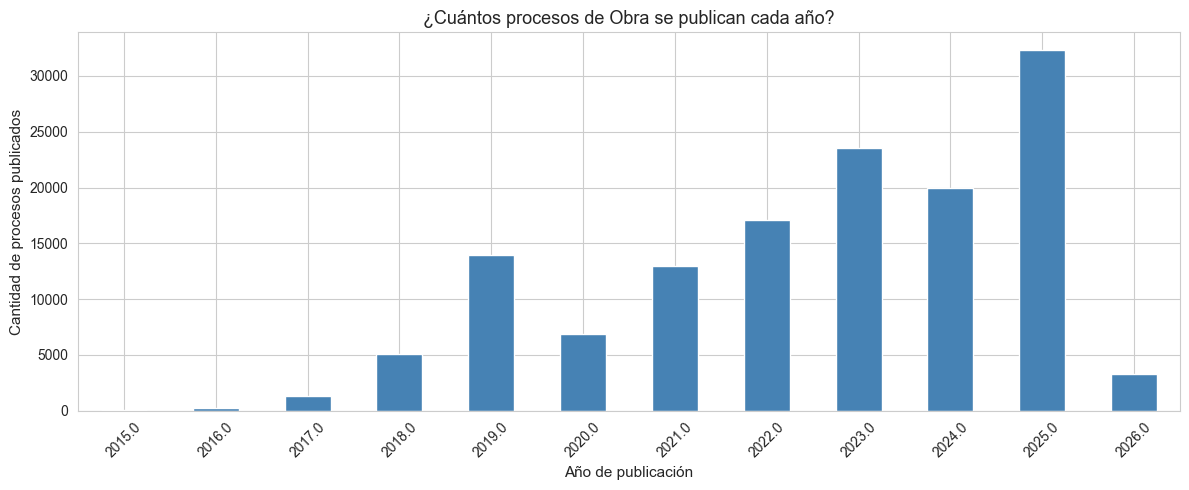


💡 Interpretación:
  - Eje X = año en que se publicó el proceso.
  - Eje Y = cuántos procesos de Obra se publicaron ese año.
  - Permite ver si la contratación pública de obras ha crecido o disminuido.
  - Años recientes pueden tener menos procesos si aún no han cerrado.


In [23]:
# Evolución temporal: procesos publicados por año
pub_col = "fecha_de_publicacion_del" if "fecha_de_publicacion_del" in df.columns else None

if pub_col and df[pub_col].notna().sum() > 0:
    df["anio_publicacion"] = df[pub_col].dt.year
    year_counts = df["anio_publicacion"].value_counts().sort_index()
    
    print("Procesos de Obra publicados por año:")
    print("="*40)
    for year, count in year_counts.items():
        pct = count / len(df) * 100
        print(f"  {int(year):>6}   {count:>8,} ({pct:5.1f}%)")
    
    fig, ax = plt.subplots(figsize=(12, 5))
    year_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_xlabel("Año de publicación", fontsize=11)
    ax.set_ylabel("Cantidad de procesos publicados", fontsize=11)
    ax.set_title("¿Cuántos procesos de Obra se publican cada año?", fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interpretación:")
    print("  - Eje X = año en que se publicó el proceso.")
    print("  - Eje Y = cuántos procesos de Obra se publicaron ese año.")
    print("  - Permite ver si la contratación pública de obras ha crecido o disminuido.")
    print("  - Años recientes pueden tener menos procesos si aún no han cerrado.")
else:
    print("No hay datos de fecha de publicación para graficar.")

### 7.1 Duración del proceso de selección

Calculamos cuántos días pasaron entre la publicación del proceso y la adjudicación.  
Este tiempo puede ser un feature: ¿procesos que tardan mucho en adjudicar tienen más problemas después?

Tiempo de selección (publicación → adjudicación):
  Registros con ambas fechas: 50,971
  Con duración positiva:      50,554
  Mínimo:           1 días
  P25:             16 días
  Mediana:         31 días
  Media:           65 días
  P75:             55 días
  P95:            130 días
  Máximo:        1074 días


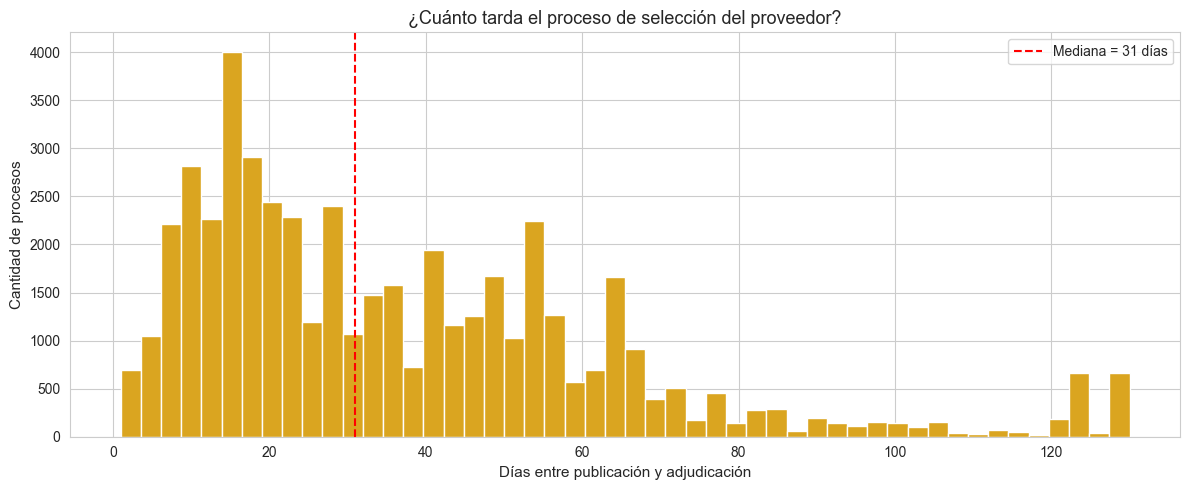


💡 Interpretación:
  - Eje X = días que tardó en adjudicarse el proceso.
  - Eje Y = cuántos procesos tardaron ese tiempo.
  - Ejemplo: si la mediana es 30, la mitad de los procesos
    tardan menos de 30 días en adjudicarse.
  - Línea roja = mediana.


In [24]:
# Calcular tiempo de selección (publicación → adjudicación)
fecha_pub = "fecha_de_publicacion_del"
fecha_adj = "fecha_adjudicacion"

if fecha_pub in df.columns and fecha_adj in df.columns:
    # Asegurar que son datetime
    df[fecha_adj] = pd.to_datetime(df[fecha_adj], errors="coerce")
    
    mask = df[fecha_pub].notna() & df[fecha_adj].notna()
    df.loc[mask, "dias_seleccion"] = (df.loc[mask, fecha_adj] - df.loc[mask, fecha_pub]).dt.days
    
    sel = df["dias_seleccion"].dropna()
    sel_pos = sel[sel > 0]  # solo positivos
    
    print(f"Tiempo de selección (publicación → adjudicación):")
    print("="*60)
    print(f"  Registros con ambas fechas: {mask.sum():,}")
    print(f"  Con duración positiva:      {len(sel_pos):,}")
    if len(sel_pos) > 0:
        print(f"  Mínimo:    {sel_pos.min():>8.0f} días")
        print(f"  P25:       {sel_pos.quantile(0.25):>8.0f} días")
        print(f"  Mediana:   {sel_pos.median():>8.0f} días")
        print(f"  Media:     {sel_pos.mean():>8.0f} días")
        print(f"  P75:       {sel_pos.quantile(0.75):>8.0f} días")
        print(f"  P95:       {sel_pos.quantile(0.95):>8.0f} días")
        print(f"  Máximo:    {sel_pos.max():>8.0f} días")
        
        # Gráfico
        fig, ax = plt.subplots(figsize=(12, 5))
        sel_viz = sel_pos[sel_pos <= sel_pos.quantile(0.95)]  # hasta P95
        ax.hist(sel_viz, bins=50, color="goldenrod", edgecolor="white")
        ax.axvline(sel_pos.median(), color="red", linestyle="--",
                   label=f"Mediana = {sel_pos.median():.0f} días")
        ax.set_xlabel("Días entre publicación y adjudicación", fontsize=11)
        ax.set_ylabel("Cantidad de procesos", fontsize=11)
        ax.set_title("¿Cuánto tarda el proceso de selección del proveedor?", fontsize=13)
        ax.legend(fontsize=10)
        plt.tight_layout()
        plt.show()
        
        print("\n💡 Interpretación:")
        print("  - Eje X = días que tardó en adjudicarse el proceso.")
        print("  - Eje Y = cuántos procesos tardaron ese tiempo.")
        print("  - Ejemplo: si la mediana es 30, la mitad de los procesos")
        print("    tardan menos de 30 días en adjudicarse.")
        print("  - Línea roja = mediana.")
else:
    print("No se pueden calcular tiempos de selección (faltan columnas de fecha).")

## 8. Número de lotes

Un proceso puede tener varios lotes (partes del contrato). Cada lote puede generar un contrato independiente.  
Esto es relevante porque la relación proceso → contrato es 1:N (un proceso puede generar varios contratos).

In [25]:
if "numero_de_lotes" in df.columns:
    lotes = df["numero_de_lotes"].dropna()
    print("Número de lotes por proceso:")
    print("="*40)
    lote_counts = df["numero_de_lotes"].value_counts().sort_index()
    for val, count in lote_counts.head(10).items():
        pct = count / len(df) * 100
        print(f"  {val:>5} lote(s): {count:>8,} procesos ({pct:5.1f}%)")
    if len(lote_counts) > 10:
        print(f"  ... y {len(lote_counts) - 10} valores más")
    
    print(f"\n  Media:   {lotes.mean():.1f} lotes")
    print(f"  Mediana: {lotes.median():.0f} lotes")
    print(f"  Máximo:  {lotes.max():.0f} lotes")
else:
    print("Columna 'numero_de_lotes' no encontrada.")

Número de lotes por proceso:
      0 lote(s):  117,989 procesos ( 85.4%)
      1 lote(s):      496 procesos (  0.4%)
      2 lote(s):    2,332 procesos (  1.7%)
      3 lote(s):    2,306 procesos (  1.7%)
      4 lote(s):    1,836 procesos (  1.3%)
      5 lote(s):    1,305 procesos (  0.9%)
      6 lote(s):      818 procesos (  0.6%)
      7 lote(s):    1,193 procesos (  0.9%)
      8 lote(s):      903 procesos (  0.7%)
      9 lote(s):      372 procesos (  0.3%)
  ... y 11 valores más

  Media:   1.7 lotes
  Mediana: 0 lotes
  Máximo:  38 lotes


## 9. Llaves de integración con contratosElectronicos

Esta sección es **crítica** para el proyecto. Necesitamos confirmar que podemos vincular cada proceso con su contrato firmado.

**Llave principal**: `id_del_proceso` (en esta tabla) = `proceso_de_compra` (en contratosElectronicos)

Verificamos:
1. ¿Cuántos procesos tienen `id_del_proceso` no nulo?
2. ¿Son únicos? (¿hay procesos duplicados?)
3. Si cargamos los contratos, ¿cuántos hacen match?

In [26]:
# Verificar llave principal
if "id_del_proceso" in df.columns:
    id_proc = df["id_del_proceso"]
    print("Llave principal: id_del_proceso")
    print("="*50)
    print(f"  Total registros:    {len(df):>10,}")
    print(f"  No nulos:           {id_proc.notna().sum():>10,}")
    print(f"  Nulos:              {id_proc.isna().sum():>10,}")
    print(f"  Valores únicos:     {id_proc.nunique():>10,}")
    print(f"  Duplicados:         {id_proc.duplicated().sum():>10,}")
    
    if id_proc.duplicated().sum() > 0:
        print(f"\n  ⚠️ Hay {id_proc.duplicated().sum():,} IDs duplicados — investigar.")
        # Mostrar algunos ejemplos
        dup_ids = id_proc[id_proc.duplicated(keep=False)].value_counts().head(5)
        print(f"  Top 5 IDs más repetidos:")
        for id_val, count in dup_ids.items():
            print(f"    {id_val}: {count} veces")
else:
    print("Columna 'id_del_proceso' no encontrada.")

Llave principal: id_del_proceso
  Total registros:       138,112
  No nulos:              138,112
  Nulos:                       0
  Valores únicos:        112,891
  Duplicados:             25,221



  ⚠️ Hay 25,221 IDs duplicados — investigar.
  Top 5 IDs más repetidos:
    CO1.REQ.8037089: 1296 veces
    CO1.REQ.976985: 1296 veces
    CO1.REQ.818918: 588 veces
    CO1.REQ.973078: 484 veces
    CO1.REQ.978941: 441 veces


In [27]:
# Cruce con contratosElectronicos (si el parquet existe)
contratos_path = Path("../data/contratos_electronicos_obra.parquet")

if contratos_path.exists():
    df_contratos = pd.read_parquet(contratos_path)
    print(f"Contratos electrónicos cargados: {len(df_contratos):,}")
    
    if "proceso_de_compra" in df_contratos.columns and "id_del_proceso" in df.columns:
        # IDs en cada tabla
        ids_procesos = set(df["id_del_proceso"].dropna())
        ids_contratos = set(df_contratos["proceso_de_compra"].dropna())
        
        match = ids_procesos & ids_contratos
        solo_procesos = ids_procesos - ids_contratos
        solo_contratos = ids_contratos - ids_procesos
        
        print(f"\nAnálisis de cruce (id_del_proceso ↔ proceso_de_compra):")
        print("="*60)
        print(f"  IDs únicos en procesosDeContratacion: {len(ids_procesos):>10,}")
        print(f"  IDs únicos en contratosElectronicos:  {len(ids_contratos):>10,}")
        print(f"  Match (están en ambas tablas):         {len(match):>10,} ({len(match)/len(ids_procesos)*100:.1f}% de procesos)")
        print(f"  Solo en procesos (sin contrato):       {len(solo_procesos):>10,}")
        print(f"  Solo en contratos (sin proceso):       {len(solo_contratos):>10,}")
        
        print("\n💡 Interpretación:")
        print("  - 'Match' = procesos que efectivamente generaron un contrato firmado.")
        print("  - 'Solo en procesos' = procesos que no generaron contrato (desiertos, cancelados, o aún en curso).")
        print("  - 'Solo en contratos' = contratos cuyo proceso no aparece en nuestros datos")
        print("    (posiblemente de otra modalidad o datos incompletos).")
    else:
        print("No se encontraron las columnas de llave para el cruce.")
else:
    print(f"Archivo de contratos no encontrado en: {contratos_path}")
    print("Ejecuta primero el notebook 01 para descargar los contratos.")

Contratos electrónicos cargados: 51,353



Análisis de cruce (id_del_proceso ↔ proceso_de_compra):
  IDs únicos en procesosDeContratacion:    112,891
  IDs únicos en contratosElectronicos:      43,451
  Match (están en ambas tablas):                  0 (0.0% de procesos)
  Solo en procesos (sin contrato):          112,891
  Solo en contratos (sin proceso):           43,451

💡 Interpretación:
  - 'Match' = procesos que efectivamente generaron un contrato firmado.
  - 'Solo en procesos' = procesos que no generaron contrato (desiertos, cancelados, o aún en curso).
  - 'Solo en contratos' = contratos cuyo proceso no aparece en nuestros datos
    (posiblemente de otra modalidad o datos incompletos).


### 9.2 HALLAZGO CRITICO: La llave correcta NO es `id_del_proceso`

El cruce anterior dio **0% de match**. Investigando los formatos de los IDs encontramos que:

- `id_del_proceso` usa el prefijo **`CO1.REQ.`** (requisicion/proceso)
- `proceso_de_compra` (en contratos) usa el prefijo **`CO1.BDOS.`** (buying order/portafolio)

Son **sistemas de numeracion diferentes** dentro de SECOP II. Sin embargo, al revisar TODAS las columnas,
encontramos que **`id_del_portafolio`** en esta tabla tambien tiene formato `CO1.BDOS.` y coincide con
`proceso_de_compra` en contratos.

| Campo en procesos | Campo en contratos | Formato | Match |
|---|---|---|---|
| ~~`id_del_proceso`~~ | `proceso_de_compra` | `CO1.REQ.` vs `CO1.BDOS.` | **0%** |
| **`id_del_portafolio`** | **`proceso_de_compra`** | Ambos `CO1.BDOS.` | **99.9%** |
| `urlproceso` (NTC) | `urlproceso` (NTC) | Ambos `CO1.NTC.` | **99.9%** |

**Conclusion**: La llave correcta de integracion es:
- `id_del_portafolio` (procesos) = `proceso_de_compra` (contratos)

Esto **corrige** la documentacion original del esquema relacional que indicaba usar `id_del_proceso`.

In [28]:
# Verificar la llave CORRECTA: id_del_portafolio <-> proceso_de_compra
if contratos_path.exists() and "id_del_portafolio" in df.columns:
    port_ids = set(df["id_del_portafolio"].dropna())
    compra_ids = set(df_contratos["proceso_de_compra"].dropna())

    match = port_ids & compra_ids
    solo_proc = port_ids - compra_ids
    solo_cont = compra_ids - port_ids

    print("Cruce CORRECTO: id_del_portafolio <-> proceso_de_compra")
    print("=" * 60)
    print(f"  IDs unicos en id_del_portafolio:  {len(port_ids):>10,}")
    print(f"  IDs unicos en proceso_de_compra:  {len(compra_ids):>10,}")
    print(f"  Match (estan en ambas tablas):     {len(match):>10,} ({len(match)/len(compra_ids)*100:.1f}% de contratos)")
    print(f"  Solo en procesos (sin contrato):   {len(solo_proc):>10,}")
    print(f"  Solo en contratos (sin proceso):   {len(solo_cont):>10,}")

    # Verificacion adicional via NTC en urlproceso
    import re
    pat = r'noticeUID=(CO1\.NTC\.\d+)'
    proc_ntc = df["urlproceso"].dropna().str.extract(pat)[0].dropna()
    cont_ntc = df_contratos["urlproceso"].dropna().str.extract(pat)[0].dropna()
    ntc_match = set(proc_ntc) & set(cont_ntc)
    print("")
    print(f"  Verificacion via NTC (urlproceso): {len(ntc_match):,} matches")

    print("")
    print("=" * 60)
    print("LLAVE DE INTEGRACION CONFIRMADA:")
    print("  procesosDeContratacion.id_del_portafolio")
    print("       = contratosElectronicos.proceso_de_compra")
    print(f"  Cobertura: {len(match)/len(compra_ids)*100:.1f}% de los contratos tienen proceso asociado")

Cruce CORRECTO: id_del_portafolio <-> proceso_de_compra
  IDs unicos en id_del_portafolio:      76,322
  IDs unicos en proceso_de_compra:      43,451
  Match (estan en ambas tablas):         43,414 (99.9% de contratos)
  Solo en procesos (sin contrato):       32,908
  Solo en contratos (sin proceso):           37



  Verificacion via NTC (urlproceso): 43,410 matches

LLAVE DE INTEGRACION CONFIRMADA:
  procesosDeContratacion.id_del_portafolio
       = contratosElectronicos.proceso_de_compra
  Cobertura: 99.9% de los contratos tienen proceso asociado


### 9.1 Llaves secundarias

Además de `id_del_proceso`, hay otros campos que podrían servir para vincular tablas.

In [29]:
# Otras llaves potenciales
llaves = {
    "codigoproveedor": "Código del proveedor adjudicado",
    "codigo_entidad": "Código de la entidad en SECOP II",
    "nit_entidad": "NIT de la entidad",
    "referencia_del_proceso": "Referencia asignada por la entidad",
    "codigo_principal_de_categoria": "Código UNSPSC"
}

print("Llaves de integración secundarias:")
print("="*70)
print(f"{'Campo':<35} {'N válidos':>10} {'Únicos':>10} {'Nulos %':>10}")
print("-"*70)
for col, desc in llaves.items():
    if col in df.columns:
        valid = df[col].notna().sum()
        unique = df[col].nunique()
        null_pct = (1 - valid/len(df)) * 100
        print(f"  {col:<33} {valid:>10,} {unique:>10,} {null_pct:>9.1f}%")
    else:
        print(f"  {col:<33} {'NO EXISTE':>10}")

Llaves de integración secundarias:
Campo                                N válidos     Únicos    Nulos %
----------------------------------------------------------------------
  codigoproveedor                      138,112     23,233       0.0%
  codigo_entidad                       138,112      5,538       0.0%
  nit_entidad                          138,112      5,266       0.0%
  referencia_del_proceso               138,112     96,938       0.0%
  codigo_principal_de_categoria        138,112      2,541       0.0%


## 10. Subtipo de contrato

Además del tipo (Obra), hay un subtipo que puede dar más detalle sobre la naturaleza del contrato.

In [30]:
if "subtipo_de_contrato" in df.columns:
    sub_counts = df["subtipo_de_contrato"].value_counts()
    print("Subtipos de contrato en procesos de Obra:")
    print("="*50)
    for val, count in sub_counts.items():
        pct = count / len(df) * 100
        print(f"  {str(val):40s} {count:>8,} ({pct:5.1f}%)")
else:
    print("Columna 'subtipo_de_contrato' no encontrada.")

Subtipos de contrato en procesos de Obra:
  No Definido                               138,112 (100.0%)


## 11. Resumen de problemas de calidad detectados

Consolidamos todos los problemas encontrados durante la exploración.

In [31]:
print("╔" + "═"*68 + "╗")
print("║" + " RESUMEN DE PROBLEMAS DE CALIDAD ".center(68) + "║")
print("╚" + "═"*68 + "╝")

# 1. Columnas con alta nulidad
print("\n1. COLUMNAS CON NULIDAD EFECTIVA > 30%:")
high_null_30 = nulidad[nulidad["nulidad_efectiva_%"] > 30]
if len(high_null_30) > 0:
    for _, row in high_null_30.iterrows():
        print(f"   - {row['columna']}: {row['nulidad_efectiva_%']:.1f}%")
else:
    print("   Ninguna columna supera el 30%.")

# 2. Duplicados
print(f"\n2. DUPLICADOS EN id_del_proceso:")
if "id_del_proceso" in df.columns:
    n_dup = df["id_del_proceso"].duplicated().sum()
    print(f"   {n_dup:,} registros duplicados de {len(df):,} total")

# 3. Tipos incorrectos
print(f"\n3. TIPOS DE DATOS:")
all_object = (df.dtypes == "object").sum()
print(f"   {all_object} columnas son tipo 'object' (texto/mixto)")
print(f"   Columnas numéricas convertidas exitosamente: {len(cols_numericas_def)}")

# 4. Sentinelas
print(f"\n4. SENTINELAS ('No Definido' y similares):")
cols_con_sentinela = nulidad[nulidad["sentinelas_%"] > 0]
if len(cols_con_sentinela) > 0:
    for _, row in cols_con_sentinela.iterrows():
        if row["sentinelas_%"] > 1:  # solo mostrar si > 1%
            print(f"   - {row['columna']}: {row['sentinelas_%']:.1f}%")
else:
    print("   No se detectaron sentinelas significativas.")

# 5. Campos de precio/valor con ceros
print(f"\n5. VALORES CERO EN CAMPOS FINANCIEROS:")
for col in ["precio_base", "valor_total_adjudicacion"]:
    if col in df.columns:
        data = df[col].dropna()
        zeros = (data == 0).sum()
        print(f"   - {col}: {zeros:,} ceros ({zeros/len(data)*100:.1f}% de los que tienen dato)")

╔════════════════════════════════════════════════════════════════════╗
║                  RESUMEN DE PROBLEMAS DE CALIDAD                   ║
╚════════════════════════════════════════════════════════════════════╝

1. COLUMNAS CON NULIDAD EFECTIVA > 30%:
   - fecha_de_publicacion: 89.8%
   - fecha_de_publicacion_fase_2: 82.9%
   - fecha_adjudicacion: 63.1%
   - fecha_de_apertura_efectiva: 31.1%

2. DUPLICADOS EN id_del_proceso:
   25,221 registros duplicados de 138,112 total

3. TIPOS DE DATOS:
   0 columnas son tipo 'object' (texto/mixto)
   Columnas numéricas convertidas exitosamente: 14

4. SENTINELAS ('No Definido' y similares):
   No se detectaron sentinelas significativas.

5. VALORES CERO EN CAMPOS FINANCIEROS:
   - precio_base: 1,389 ceros (1.0% de los que tienen dato)
   - valor_total_adjudicacion: 82,297 ceros (59.6% de los que tienen dato)


## 12. Clasificación de columnas para modelado

Clasificamos las 59 columnas según su utilidad para el modelo predictivo.

| Categoría | Descripción |
|---|---|
| **ID / Llave** | Identificadores para vincular tablas |
| **Feature - Entidad** | Información de la entidad contratante |
| **Feature - Competencia** | Variables sobre participación de proveedores |
| **Feature - Contractual** | Tipo, modalidad, subtipo, duración |
| **Feature - Temporal** | Fechas del proceso |
| **Feature - Financiero** | Precio base, valor adjudicación |
| **Descartable** | URLs, nombres de personas, campos vacíos |

In [32]:
# Clasificación de columnas
clasificacion = {
    "ID / Llave": ["id_del_proceso", "referencia_del_proceso", "id_del_portafolio", "ppi",
                   "codigo_entidad", "nit_entidad", "codigoproveedor",
                   "id_adjudicacion", "id_estado_del_procedimiento"],
    "Feature - Entidad": ["entidad", "departamento_entidad", "ciudad_entidad", 
                          "ordenentidad", "codigo_pci",
                          "ciudad_de_la_unidad_de", "nombre_de_la_unidad_de"],
    "Feature - Competencia": ["proveedores_invitados", "proveedores_con_invitacion",
                              "visualizaciones_del", "proveedores_que_manifestaron",
                              "respuestas_al_procedimiento", "respuestas_externas",
                              "conteo_de_respuestas_a_ofertas", "proveedores_unicos_con"],
    "Feature - Contractual": ["modalidad_de_contratacion", "justificaci_n_modalidad_de",
                              "tipo_de_contrato", "subtipo_de_contrato",
                              "duracion", "unidad_de_duracion", "numero_de_lotes",
                              "nombre_del_procedimiento", "descripci_n_del_procedimiento",
                              "codigo_principal_de_categoria", "categorias_adicionales"],
    "Feature - Estado": ["fase", "estado_del_procedimiento", "adjudicado",
                         "estado_de_apertura_del_proceso", "estado_resumen"],
    "Feature - Temporal": ["fecha_de_publicacion_del", "fecha_de_ultima_publicaci",
                           "fecha_de_publicacion_fase", "fecha_de_publicacion_fase_1",
                           "fecha_de_publicacion", "fecha_de_publicacion_fase_2",
                           "fecha_de_publicacion_fase_3",
                           "fecha_de_recepcion_de", "fecha_de_apertura_de_respuesta",
                           "fecha_de_apertura_efectiva", "fecha_adjudicacion"],
    "Feature - Financiero": ["precio_base", "valor_total_adjudicacion"],
    "Descartable": ["urlproceso", "nombre_del_adjudicador", "nombre_del_proveedor",
                    "nit_del_proveedor_adjudicado", "departamento_proveedor", "ciudad_proveedor"]
}

print("Clasificación de las columnas para modelado:")
print("="*60)
total_clasificadas = 0
for cat, cols in clasificacion.items():
    presentes = [c for c in cols if c in df.columns]
    ausentes = [c for c in cols if c not in df.columns]
    print(f"\n{cat} ({len(presentes)} presentes):")
    for c in presentes:
        print(f"  ✓ {c}")
    for c in ausentes:
        print(f"  ✗ {c} (no existe en datos)")
    total_clasificadas += len(cols)

# Columnas no clasificadas
todas_clasificadas = set()
for cols in clasificacion.values():
    todas_clasificadas.update(cols)

sin_clasificar = set(df.columns) - todas_clasificadas
if sin_clasificar:
    print(f"\nColumnas NO clasificadas ({len(sin_clasificar)}):")
    for c in sorted(sin_clasificar):
        print(f"  ? {c}")

Clasificación de las columnas para modelado:

ID / Llave (9 presentes):
  ✓ id_del_proceso
  ✓ referencia_del_proceso
  ✓ id_del_portafolio
  ✓ ppi
  ✓ codigo_entidad
  ✓ nit_entidad
  ✓ codigoproveedor
  ✓ id_adjudicacion
  ✓ id_estado_del_procedimiento

Feature - Entidad (7 presentes):
  ✓ entidad
  ✓ departamento_entidad
  ✓ ciudad_entidad
  ✓ ordenentidad
  ✓ codigo_pci
  ✓ ciudad_de_la_unidad_de
  ✓ nombre_de_la_unidad_de

Feature - Competencia (8 presentes):
  ✓ proveedores_invitados
  ✓ proveedores_con_invitacion
  ✓ visualizaciones_del
  ✓ proveedores_que_manifestaron
  ✓ respuestas_al_procedimiento
  ✓ respuestas_externas
  ✓ conteo_de_respuestas_a_ofertas
  ✓ proveedores_unicos_con

Feature - Contractual (11 presentes):
  ✓ modalidad_de_contratacion
  ✓ justificaci_n_modalidad_de
  ✓ tipo_de_contrato
  ✓ subtipo_de_contrato
  ✓ duracion
  ✓ unidad_de_duracion
  ✓ numero_de_lotes
  ✓ nombre_del_procedimiento
  ✓ descripci_n_del_procedimiento
  ✓ codigo_principal_de_categoria
 

## 13. Variables más valiosas para el modelo predictivo

De esta fuente, las variables **más prometedoras** como features son las de competencia y las financieras pre-contrato, porque:
1. Existen ANTES de la firma del contrato (no son leakage)
2. Caracterizan el nivel de transparencia y competitividad del proceso
3. Complementan la información que no tiene contratosElectronicos

In [33]:
print("╔" + "═"*68 + "╗")
print("║" + " VARIABLES MÁS VALIOSAS PARA MODELADO ".center(68) + "║")
print("╚" + "═"*68 + "╝")

variables_top = {
    "Competencia (pre-contrato)": {
        "proveedores_invitados": "Cuántos proveedores fueron invitados",
        "proveedores_que_manifestaron": "Cuántos mostraron interés real",
        "proveedores_unicos_con": "Cuántos enviaron oferta",
        "visualizaciones_del": "Visibilidad del proceso en la plataforma",
    },
    "Financiero (pre-contrato)": {
        "precio_base": "Estimación del costo antes de adjudicar",
        "valor_total_adjudicacion": "Valor por el que se adjudicó (vs precio_base)",
    },
    "Contractual": {
        "modalidad_de_contratacion": "Mecanismo de selección",
        "subtipo_de_contrato": "Subtipo dentro de Obra",
        "duracion": "Duración estimada del contrato",
        "numero_de_lotes": "Complejidad del proceso (más lotes = más complejo)",
    },
    "Feature derivado potencial": {
        "ratio_adj_base": "valor_total_adjudicacion / precio_base (subestimación)",
        "dias_seleccion": "Tiempo de publicación a adjudicación",
        "ratio_ofertas_invitados": "proveedores_unicos_con / proveedores_invitados (tasa de participación)",
    }
}

for cat, vars_dict in variables_top.items():
    print(f"\n{cat}:")
    for var, desc in vars_dict.items():
        existe = "✓" if var in df.columns else "[derivada]"
        print(f"  {existe} {var}: {desc}")

╔════════════════════════════════════════════════════════════════════╗
║                VARIABLES MÁS VALIOSAS PARA MODELADO                ║
╚════════════════════════════════════════════════════════════════════╝

Competencia (pre-contrato):
  ✓ proveedores_invitados: Cuántos proveedores fueron invitados
  ✓ proveedores_que_manifestaron: Cuántos mostraron interés real
  ✓ proveedores_unicos_con: Cuántos enviaron oferta
  ✓ visualizaciones_del: Visibilidad del proceso en la plataforma

Financiero (pre-contrato):
  ✓ precio_base: Estimación del costo antes de adjudicar
  ✓ valor_total_adjudicacion: Valor por el que se adjudicó (vs precio_base)

Contractual:
  ✓ modalidad_de_contratacion: Mecanismo de selección
  ✓ subtipo_de_contrato: Subtipo dentro de Obra
  ✓ duracion: Duración estimada del contrato
  ✓ numero_de_lotes: Complejidad del proceso (más lotes = más complejo)

Feature derivado potencial:
  [derivada] ratio_adj_base: valor_total_adjudicacion / precio_base (subestimación)
  ✓ 

## 14. Conclusiones — Evaluación estratégica CRISP-DM

### ¿Qué encontramos?

La fuente `procesosDeContratacion` contiene información valiosa de la **fase pre-contrato** que complementa a la fuente madre (`contratosElectronicos`). Las variables de competencia (cuántos proveedores participaron, cuántas ofertas se recibieron) son especialmente útiles porque:

1. **No causan leakage**: toda la información existe antes de firmar el contrato
2. **Son predictivas intuitivamente**: un proceso con poca competencia podría indicar mayor riesgo
3. **Son numéricas y listas para modelar**: no requieren procesamiento complejo

### ¿Qué sigue?

- **Próximo notebook**: `03_adiciones.ipynb` — explorar las modificaciones contractuales (adiciones en valor, extensiones de plazo)
- **Pendiente**: verificar la cardinalidad del cruce proceso → contrato con datos reales
- **Riesgo**: si muchos contratos no tienen proceso asociado, perderíamos features al hacer el JOIN

In [34]:
print("Resumen final:")
print("="*60)
print(f"  Total procesos de Obra descargados: {len(df):,}")
if "id_del_proceso" in df.columns:
    print(f"  IDs únicos:                        {df['id_del_proceso'].nunique():,}")
print(f"  Columnas totales:                  {len(df.columns)}")
print(f"  Columnas con >50% nulidad:         {len(nulidad[nulidad['nulidad_efectiva_%'] > 50])}")
print(f"  Features potenciales:              ~20 (competencia + financiero + contractual + temporal)")
print(f"  Archivo guardado:                  data/procesos_contratacion_obra.parquet")

Resumen final:
  Total procesos de Obra descargados: 138,112
  IDs únicos:                        112,891
  Columnas totales:                  60
  Columnas con >50% nulidad:         3
  Features potenciales:              ~20 (competencia + financiero + contractual + temporal)
  Archivo guardado:                  data/procesos_contratacion_obra.parquet
